<a href="https://colab.research.google.com/github/L-Carlos/aulas-machine-learning/blob/main/ML_aula3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint: Machine Learning & Analytics - PUC Rio (2026)
---
## Aula 3.2
### Pipelines

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              ExtraTreesClassifier, VotingClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)


In [2]:
url = "https://raw.githubusercontent.com/tatianaesc/datascience/main/diabetes.csv"

In [3]:
dataset = pd.read_csv(url, delimiter=",")

dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
test_size = 0.2
seed = 2026

X = dataset.drop(columns="Outcome")
y = dataset["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, shuffle=True, random_state=seed, stratify=y
    )

scoring = "accuracy"
n_splits = 10
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

LR         Media: 0.798  Desv. Pad.: 0.049
KNN        Media: 0.752  Desv. Pad.: 0.050
CART       Media: 0.694  Desv. Pad.: 0.052
NB         Media: 0.775  Desv. Pad.: 0.052
SVM        Media: 0.774  Desv. Pad.: 0.045
Bagging    Media: 0.757  Desv. Pad.: 0.042
RF         Media: 0.783  Desv. Pad.: 0.044
ET         Media: 0.793  Desv. Pad.: 0.024
ADA        Media: 0.772  Desv. Pad.: 0.058
GB         Media: 0.775  Desv. Pad.: 0.047
Voting     Media: 0.790  Desv. Pad.: 0.048


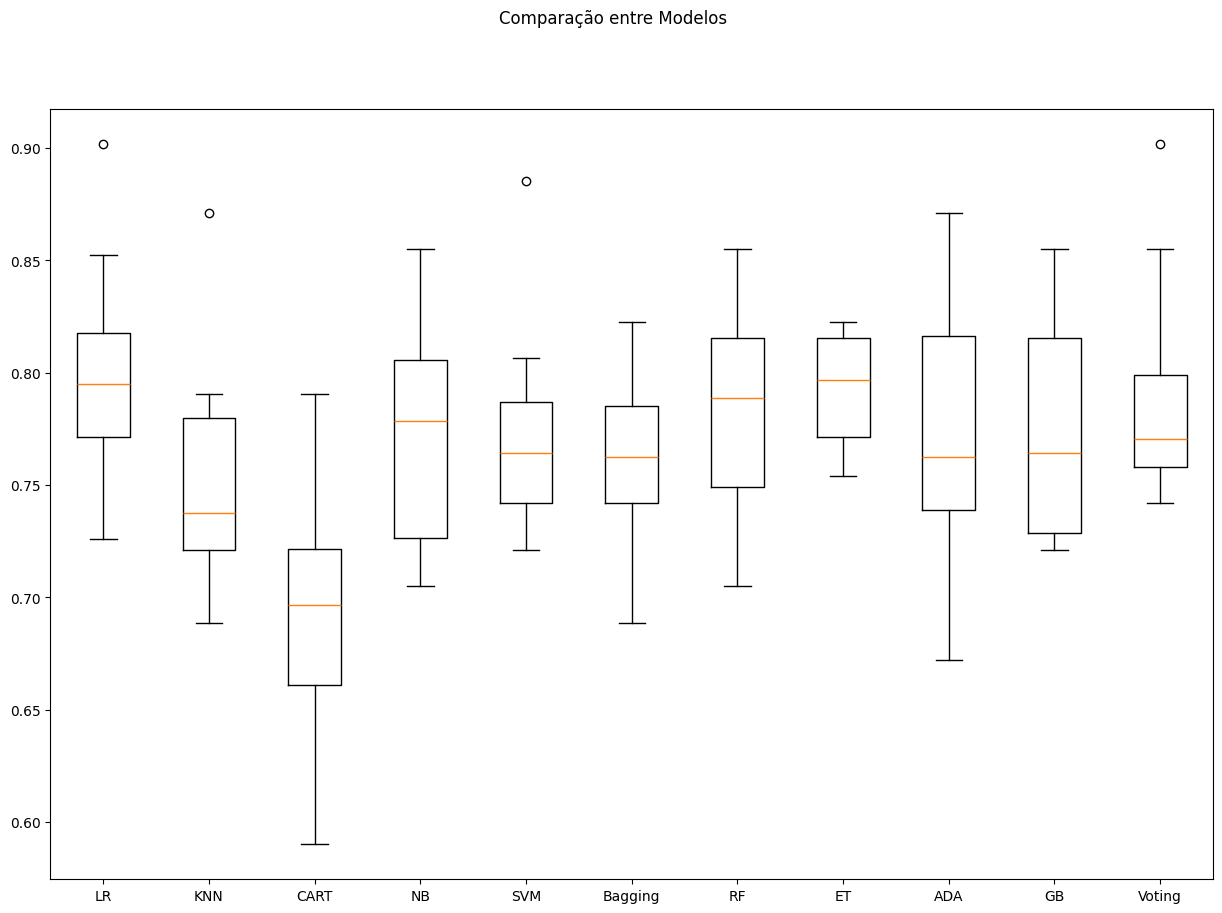

In [12]:
np.random.seed(seed)

models = []

models.append(("LR", LogisticRegression(max_iter=200)))
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC()))

base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

bases = []

model1 = LogisticRegression(max_iter=200)
bases.append(("logistic", model1))

model2 = DecisionTreeClassifier()
bases.append(("cart", model2))

model3 = SVC()
bases.append(("svm", model3))



models.append(("Bagging", BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(("RF", RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(("ET", ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(("ADA", AdaBoostClassifier(n_estimators=num_trees)))
models.append(("GB", GradientBoostingClassifier(n_estimators=num_trees)))
models.append(("Voting", VotingClassifier(bases)))

results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)

    print(f"{name:<10} Media: {cv_results.mean():.3f}  Desv. Pad.: {cv_results.std():.3f}")

fig = plt.figure(figsize=(15, 10))
fig.suptitle("Comparação entre Modelos")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

LR-orig        Media: 0.798  Desv. Pad.: 0.049
KNN-orig       Media: 0.752  Desv. Pad.: 0.050
CART-orig      Media: 0.700  Desv. Pad.: 0.061
NB-orig        Media: 0.775  Desv. Pad.: 0.052
SVM-orig       Media: 0.774  Desv. Pad.: 0.045
Bag-orig       Media: 0.765  Desv. Pad.: 0.052
RF-orig        Media: 0.777  Desv. Pad.: 0.045
ET-orig        Media: 0.791  Desv. Pad.: 0.035
Ada-orig       Media: 0.772  Desv. Pad.: 0.058
GB-orig        Media: 0.775  Desv. Pad.: 0.050
Vot-orig       Media: 0.780  Desv. Pad.: 0.050
LR-padr        Media: 0.798  Desv. Pad.: 0.052
KNN-padr       Media: 0.769  Desv. Pad.: 0.041
CART-padr      Media: 0.690  Desv. Pad.: 0.053
NB-padr        Media: 0.775  Desv. Pad.: 0.052
SVM-padr       Media: 0.777  Desv. Pad.: 0.057
Bag-padr       Media: 0.762  Desv. Pad.: 0.042
RF-padr        Media: 0.780  Desv. Pad.: 0.037
ET-padr        Media: 0.774  Desv. Pad.: 0.037
Ada-padr       Media: 0.772  Desv. Pad.: 0.058
GB-padr        Media: 0.774  Desv. Pad.: 0.047
Vot-padr     

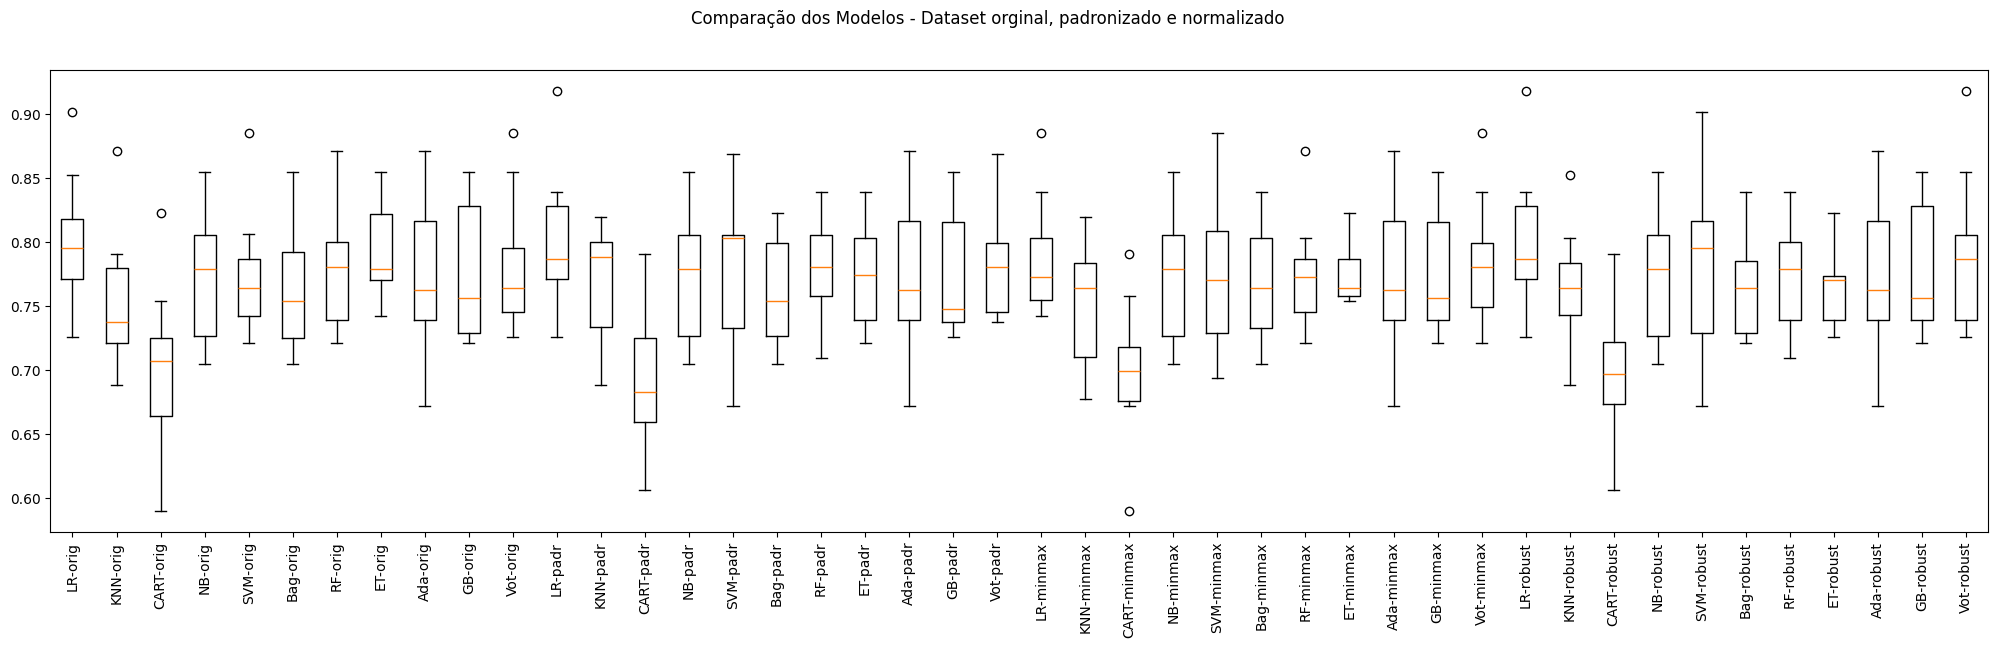

In [19]:
pipelines = []
results = []
names = []

reg_log  = ('LR', LogisticRegression(max_iter=200))
knn = ("KNN", KNeighborsClassifier())
cart = ("CART", DecisionTreeClassifier())
naive_bayes = ("NB", GaussianNB())
svm = ("SVM", SVC())
bagging = ("Bag", BaggingClassifier(estimator=base, n_estimators=num_trees))
random_forest = ("RF", RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ("ET", ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ("Ada", AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ("GB", GradientBoostingClassifier(n_estimators=num_trees))
voting = ("Voting", VotingClassifier(bases))


standard_scaler = ("StandardScaler", StandardScaler())
min_max_scaler = ("MinMaxScaler", MinMaxScaler())
robust_scaler = ("RobustScaler", RobustScaler())

pipelines.append(('LR-orig', Pipeline([reg_log])))
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))
pipelines.append(('Bag-orig', Pipeline([bagging])))
pipelines.append(('RF-orig', Pipeline([random_forest])))
pipelines.append(('ET-orig', Pipeline([extra_trees])))
pipelines.append(('Ada-orig', Pipeline([adaboost])))
pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
pipelines.append(('Vot-orig', Pipeline([voting])))


pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

pipelines.append(('LR-minmax', Pipeline([min_max_scaler, reg_log])))
pipelines.append(('KNN-minmax', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-minmax', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-minmax', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-minmax', Pipeline([min_max_scaler, svm])))
pipelines.append(('Bag-minmax', Pipeline([min_max_scaler, bagging])))
pipelines.append(('RF-minmax', Pipeline([min_max_scaler, random_forest])))
pipelines.append(('ET-minmax', Pipeline([min_max_scaler, extra_trees])))
pipelines.append(('Ada-minmax', Pipeline([min_max_scaler, adaboost])))
pipelines.append(('GB-minmax', Pipeline([min_max_scaler, gradient_boosting])))
pipelines.append(('Vot-minmax', Pipeline([min_max_scaler, voting])))

pipelines.append(('LR-robust', Pipeline([robust_scaler, reg_log])))
pipelines.append(('KNN-robust', Pipeline([robust_scaler, knn])))
pipelines.append(('CART-robust', Pipeline([robust_scaler, cart])))
pipelines.append(('NB-robust', Pipeline([robust_scaler, naive_bayes])))
pipelines.append(('SVM-robust', Pipeline([robust_scaler, svm])))
pipelines.append(('Bag-robust', Pipeline([robust_scaler, bagging])))
pipelines.append(('RF-robust', Pipeline([robust_scaler, random_forest])))
pipelines.append(('ET-robust', Pipeline([robust_scaler, extra_trees])))
pipelines.append(('Ada-robust', Pipeline([robust_scaler, adaboost])))
pipelines.append(('GB-robust', Pipeline([robust_scaler, gradient_boosting])))
pipelines.append(('Vot-robust', Pipeline([robust_scaler, voting])))


for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)

    print(f"{name:<14} Media: {cv_results.mean():.3f}  Desv. Pad.: {cv_results.std():.3f}")


fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

In [34]:
np.random.seed(seed)

pipelines = []

knn = ("KNN", KNeighborsClassifier())

standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())
robust_scaler = ("RobustScaler", RobustScaler())

pipelines.append(('knn-orig', Pipeline(steps=[knn])))
pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))
pipelines.append(('knn-robust', Pipeline(steps=[robust_scaler, knn])))


param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}


for name, model in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)

    print(f"Sem tratamento de missings: {name:<10} - Melhor: {grid.best_score_:.2f} usando: {grid.best_params_}")


Sem tratamento de missings: knn-orig   - Melhor: 0.78 usando: {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 9}
Sem tratamento de missings: knn-padr   - Melhor: 0.77 usando: {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 17}
Sem tratamento de missings: knn-norm   - Melhor: 0.78 usando: {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 17}
Sem tratamento de missings: knn-robust - Melhor: 0.78 usando: {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 17}


In [42]:
scaler = RobustScaler().fit(X_train)
scaled_X = scaler.transform(X_train)
model = LogisticRegression(max_iter=200)
model.fit(scaled_X, y_train)

scaled_test_X = scaler.transform(X_test)
predictions = model.predict(scaled_test_X)

print(f"{accuracy_score(y_test, predictions):.2f}")

0.69


In [43]:
scaler = RobustScaler().fit(X)
scaled_X = scaler.transform(X)
model.fit(scaled_X, y)

LogisticRegression(max_iter=200)

In [53]:
data = {'Pregnancies':  [1, 9, 5],
        'Glucose': [90, 100, 110],
        'BloodPressure': [50, 60, 50],
        'SkinThickness': [30, 30, 30],
        'Insulin': [100, 100, 100],
        'BMI': [20.0, 30.0, 40.0],
        'DiabetesPedigreeFunction': [1.0, 2.0, 1.0],
        'Age': [15, 40, 40],
        }


entrada = pd.DataFrame(data)

X_entrada = entrada

rescaledEntradaX = scaler.transform(X_entrada)
print(rescaledEntradaX)

[[-0.4        -0.65454545 -1.22222222  0.21875     0.54616896 -1.29032258
   1.64052288 -0.82352941]
 [ 1.2        -0.41212121 -0.66666667  0.21875     0.54616896 -0.21505376
   4.25490196  0.64705882]
 [ 0.4        -0.16969697 -1.22222222  0.21875     0.54616896  0.86021505
   1.64052288  0.64705882]]


In [54]:
saidas = model.predict(rescaledEntradaX)
print(saidas)

[0 1 1]
